In [1]:
import os
import yaml
import h5py
import numpy as np
import matplotlib.pyplot as plt
from gwpy.segments import Segment
from gwpy.segments import SegmentList
from gw_anomaly_detection.data.segments import SegmentInfo
from gw_anomaly_detection.data.s3_utils import S3_session
from gw_anomaly_detection.data.waveforms import Waveforms
from gw_anomaly_detection.data.process import Process


In [2]:
os.chdir('/home/chiajui/gw-anomaly-detection')
print(os.getcwd())

/home/chiajui/gw-anomaly-detection


### Loading data_config.yaml

In [3]:
with open("./data_config.yaml", "r") as file:
    config = yaml.safe_load(file)

ifos = config['data']['ifos']
data_cache = config['data']['data_cache']
asd_cache = config['data']['asd_cache']
injection = config['data']['injection']
output_file = config['data']['output_file']
keep_waveform = config['data']['gw_anomaly']['keep_waveform']
background_segment_files = config['data']['background']['segment_files']
background_output_file = config['data']['background']['output_file']
glitch_info_files = config['data']['glitch']['info_files']
glitch_segment_files = config['data']['glitch']['segment_files']
glitch_output_file = config['data']['glitch']['output_file']

### Loading the information of the target segments.

In [4]:
bg_segs = dict.fromkeys(ifos)
glitch_segs = dict.fromkeys(ifos)
bg_interval = dict.fromkeys(ifos)
glitch_interval = dict.fromkeys(ifos)
for ifo in ifos:
    seg_info = SegmentInfo()
    bg_segs[ifo] = seg_info.read_segment_files(background_segment_files[ifo])
    bg_interval[ifo] = seg_info.whole_segment(background_segment_files[ifo])
    glitch_segs[ifo] = seg_info.read_segment_files(glitch_segment_files[ifo])
    glitch_interval[ifo] = seg_info.whole_segment(glitch_segment_files[ifo])

    print(f"Number of background segments from {ifo}: {len(bg_segs[ifo])}, interval: {bg_interval[ifo]}.")
    print(f"Number of glitch segments from {ifo}: {len(glitch_segs[ifo])}, interval: {glitch_interval[ifo]}.")

Number of background segments from H1: 60000, interval: (1238172998.3051045, 1238196783.9474447).
Number of glitch segments from H1: 2284, interval: (1238172987.100586, 1238196787.949218).
Number of background segments from L1: 60000, interval: (1238205077.3749044, 1238228882.9574175).
Number of glitch segments from L1: 2589, interval: (1238205083.079101, 1238228839.553711).


### Generating Waveform.

In [10]:
waveform = config['data']['gw_anomaly']['waveform']
qm_file = config['data']['gw_anomaly']['qm_file']
sampling_frequency = config['data']['gw_anomaly']['sampling_frequency']
length = config['data']['gw_anomaly']['length']
number = 3
wav = Waveforms(
    ifos=ifos,
    length=length,
    sampling_frequency=sampling_frequency,
)
waveforms, params = wav.generate_waveforms(
    waveform,
    number,
    qm_file=qm_file,
)

TimeSeries([2.02851421e-28, 2.05306143e-28, 2.07712673e-28, ...,
            4.24484910e-28, 4.02073720e-28, 3.79582575e-28]
           unit: dimensionless,
           t0: 0.0 s,
           dt: 6.103515625e-05 s,
           name: H1:BBH_SIG,
           channel: H1:BBH_SIG)
4.0 s
TimeSeries([-2.80353323e-28, -2.81946356e-28, -2.83535757e-28,
            ...,  1.16864119e-27,  1.17580243e-27,
             1.18286911e-27]
           unit: dimensionless,
           t0: 0.0 s,
           dt: 6.103515625e-05 s,
           name: L1:BBH_SIG,
           channel: L1:BBH_SIG)
4.0 s


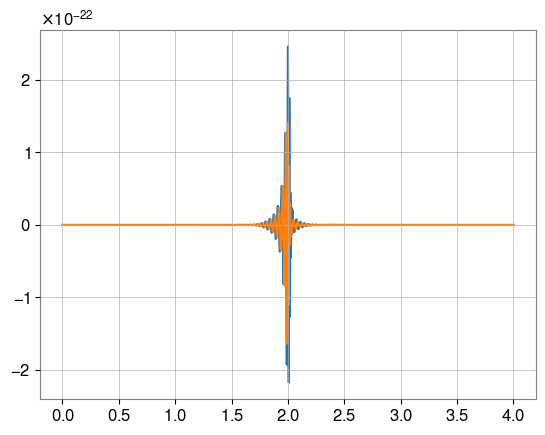

In [11]:
id = 1
print(waveforms[id]['H1'])
print(waveforms[id]['H1'].duration)
print(waveforms[id]['L1'])
print(waveforms[id]['L1'].duration)
plt.figure()
plt.plot(waveforms[id]['H1'])
plt.plot(waveforms[id]['L1'])
plt.show()

### Rescaling and Injection

In [12]:
flow = config['data']['processing']['flow']
fhigh = config['data']['processing']['fhigh']
resample = config['data']['processing']['resample']
crop_length = config['data']['processing']['crop_length']
target_snr_low = config['data']['gw_anomaly']['target_snr_low']
target_snr_high = config['data']['gw_anomaly']['target_snr_high']
proc = Process(
    ifos=ifos,
    data_cache=data_cache,
    asd_cache=asd_cache,
)
injected_ts, rescaled_waveforms, snrs = proc.inject(
    waveforms=waveforms,
    target_snr_low=target_snr_low,
    target_snr_high=target_snr_high,
    background_segments=bg_segs,
)

### Processing data.

In [13]:
timeseries = injected_ts
processed_data = proc.get_proccessed_data(
    timeseries=timeseries,
    background_segments=bg_segs,
    flow=flow,
    fhigh=fhigh,
    resample=resample,
    crop_length=crop_length,
)
timeseries = rescaled_waveforms
processed_waveforms = proc.get_proccessed_data(
    timeseries=timeseries,
    background_segments=bg_segs,
    flow=flow,
    fhigh=fhigh,
    resample=resample,
    crop_length=crop_length,
)

### Write data to hdf5 files

In [14]:
print(f"params: {len(params)}")
print(f"waveforms: {len(processed_waveforms)}")
print(f"snrs: {len(snrs)}")
print(f"processed_data: {len(processed_data)}")

print("")
print(waveform)
# print(params[0])
# print(snrs[0])

# Write data to hdf5 files.
proc.write_injection_data(
    output_file=output_file,
    waveform_parameters=params,
    snrs=snrs,
    processed_data=processed_data,
    processed_waveforms=processed_waveforms,
)

params: 3
waveforms: 3
snrs: 3
processed_data: 3

bbh


### Checking written processed data

<KeysViewHDF5 ['H1', 'L1', 't0_H1', 't0_L1', 'waveform_H1', 'waveform_L1', 'waveform_parameters']>
<HDF5 dataset "waveform_parameters": shape (3,), type "|V224">
('Mc', 'q', 'a1', 'a2', 'tilt1', 'tilt2', 'phi12', 'phijl', 'thetajn', 'distance', 'phase', 'ra', 'dec', 'psi', 'mass1', 'mass2', 'f_ref', 'inclination', 'spin1x', 'spin1y', 'spin1z', 'spin2x', 'spin2y', 'spin2z', 'approximant', 'snr_H1', 'snr_L1', 'network_snr')
<HDF5 dataset "t0_H1": shape (3,), type "<f8">
<HDF5 dataset "H1": shape (3, 8192), type "<f8">
4096.0
<HDF5 dataset "waveform_H1": shape (3, 8192), type "<f8">
H1:BBH_SIG
<HDF5 dataset "t0_L1": shape (3,), type "<f8">
<HDF5 dataset "L1": shape (3, 8192), type "<f8">
4096.0
<HDF5 dataset "waveform_L1": shape (3, 8192), type "<f8">
L1:BBH_SIG


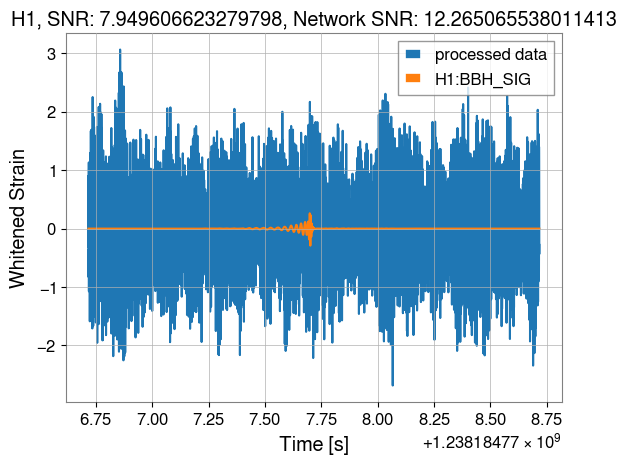

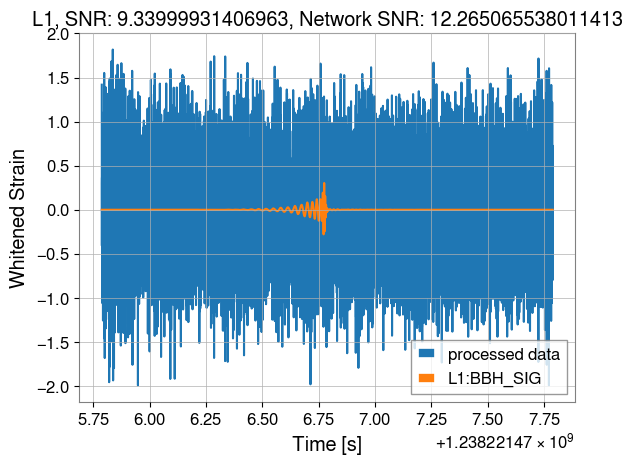

In [5]:
with h5py.File(output_file, 'r') as f:
    print(f.keys())
    print(f['waveform_parameters'])
    print(f['waveform_parameters'].dtype.names)
    print(f['t0_H1'])
    print(f['H1'])
    print(f['H1'].attrs['sample_rate'])
    print(f['waveform_H1'])
    print(f['waveform_H1'].attrs['channel'])
    print(f['t0_L1'])
    print(f['L1'])
    print(f['L1'].attrs['sample_rate'])
    print(f['waveform_L1'])
    print(f['waveform_L1'].attrs['channel'])

    id = 0
    for ifo in ifos:
        t0 = f[f't0_{ifo}'][id]
        sample_rate = f[ifo].attrs['sample_rate']
        times = np.arange(t0, t0+2, 1/sample_rate)
        waveform = f[f"waveform_{ifo}"].attrs['channel']
        snr = f['waveform_parameters'][id][f'snr_{ifo}']
        network_snr = f['waveform_parameters'][id][f'network_snr']
        plt.figure()
        plt.title(f"{ifo}, SNR: {snr}, Network SNR: {network_snr}")
        plt.plot(times, f[ifo][id], label='processed data')
        plt.plot(times, f[f'waveform_{ifo}'][id], label=waveform)
        plt.xlabel("Time [s]")
        plt.ylabel("Whitened Strain")
        plt.legend()
        plt.show()

### Processing glitches

In [5]:
# noise_segments = bg_segs
proc = Process(
    ifos=ifos,
    data_cache=data_cache,
    asd_cache=asd_cache,
)
noise_segments = glitch_segs
for ifo in ifos:
    processed_noise = proc.get_processed_noise(
        noise_segments=glitch_segs,
        start_id=0,
        end_id=3,
    )

print(processed_noise)

{'H1': [<TimeSeries([ 0.49578599, -0.3219597 , -0.10184571, ...,
              0.44008793,  1.78850445, -0.3722668 ]
            unit=Unit(dimensionless),
            t0=<Quantity 1.2381845e+09 s>,
            dt=<Quantity 0.00024414 s>,
            name='Strain',
            channel=None)>, <TimeSeries([ 0.04670676, -0.19169869,  0.65099281, ...,
             -0.35514572, -0.62831932,  0.05434112]
            unit=Unit(dimensionless),
            t0=<Quantity 1.23819411e+09 s>,
            dt=<Quantity 0.00024414 s>,
            name='Strain',
            channel=None)>, <TimeSeries([-0.02639595,  1.44179468,  0.0254139 , ...,
              0.63709757,  1.45956441,  0.83332795]
            unit=Unit(dimensionless),
            t0=<Quantity 1.23818936e+09 s>,
            dt=<Quantity 0.00024414 s>,
            name='Strain',
            channel=None)>], 'L1': [<TimeSeries([-0.14109134,  1.17546191,  1.03836064, ...,
             -0.54402656,  0.34669138,  0.45939339]
            unit=U

### Write processed noise to hdf5 files.

In [ ]:
ifo = 'H1'
with h5py.File(glitch_info_files[ifo][0], 'r') as f:
    times = f['glitch_info']['time'][:]

for i, time in enumerate(times):
    if time > glitch_interval[ifo][0] and time < glitch_interval[ifo][1]:
        print(i, time)

4429 1238205085.079101
4430 1238205086.521484
4431 1238205092.138183
4432 1238205095.128662
4433 1238205096.396606
4434 1238205113.160156
4435 1238205118.75415
4436 1238205147.889282
4437 1238205153.753906
4438 1238205156.636718
4439 1238205167.172851
4440 1238205170.773925
4441 1238205176.636718
4442 1238205185.592407
4443 1238205194.020019
4444 1238205196.992187
4445 1238205200.841552
4446 1238205202.358398
4447 1238205209.940429
4448 1238205211.21289
4449 1238205218.541992
4450 1238205225.030273
4451 1238205231.857788
4452 1238205256.605468
4453 1238205260.942382
4454 1238205283.560547
4455 1238205293.643554
4456 1238205295.589843
4457 1238205325.560058
4458 1238205327.682129
4459 1238205413.460449
4460 1238205414.707641
4461 1238205449.777343
4462 1238205453.239257
4463 1238205474.169922
4464 1238205477.292846
4465 1238205482.35083
4466 1238205490.974487
4467 1238205504.693359
4468 1238205507.933593
4469 1238205520.988891
4470 1238205552.192382
4471 1238205555.728515
4472 123820556

In [6]:
ifo = 'L1'
kind = 'glitch'
output_file = glitch_output_file
print(glitch_interval)
print(len(glitch_segs[ifo]))
for seg in glitch_segs[ifo]:
    if seg.start <= glitch_interval[ifo][0]:
        print("check samll")
        print(seg)
    if seg.end >= glitch_interval[ifo][1]:
        print("check big")
        print(seg)

# for ifo in ifos:
#     print(ifo)
#     segs = [
#         (ts.t0.value, ts.t0.value + ts.duration.value)
#         for ts in processed_noise[ifo]
#     ]

#     times = np.array([])
#     for file in glitch_info_files[ifo]:
#         with h5py.File(file, 'r') as f:
#             print(f['glitch_info'].dtype.names)
#             trig_times = f['glitch_info']['time'][:]
#             times = np.append(times, trig_times)

#     print(len(times))
#     segs.sort(key=lambda tup: tup[0])
#     print(segs)

{'H1': (1238172987.100586, 1238196787.949218), 'L1': (1238205083.079101, 1238228839.553711)}
2589
check samll
[1238205083.079101 ... 1238205087.079101)
check big
[1238228835.553711 ... 1238228839.553711)
